In [1]:
import os
import sys

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2026-03-19 01:48:05.604922: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
sys.path.append(os.pardir)
from rsmine.mi_estimator.MI_estimators import VBMI

/Users/dorukefegokmen/Desktop/ib-reg_seq_code/RSMI-NE/examples/../rsmine/coarsegrainer/build_dataset.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
def sample_correlated_gaussian(rho=0.5, dim=20, n=1, batch_size=128):
  """Generate samples from a correlated Gaussian distribution."""
  x, eps = tf.split(tf.random.normal((batch_size, 2 * dim, n)), 2, axis=1)
  y = rho * x + tf.sqrt(tf.cast(1. - rho**2, tf.float32)) * eps
  return x, y


def rho_to_mi(dim, rho):
  return -0.5 * np.log(1-rho**2) * dim


def mi_to_rho(dim, mi):
  return np.sqrt(1-np.exp(-2.0 / dim * mi))


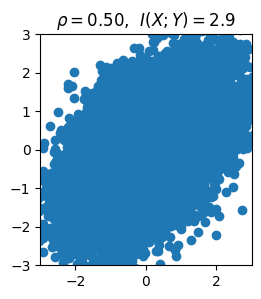

In [4]:
N_samples = 20000
batch_size = 256
L_E = 20
n = 1

plt.figure(figsize=(6, 3))
for i, rho in enumerate([0.5]):
  plt.subplot(1, 2, i + 1)
  x, y = sample_correlated_gaussian(
      batch_size=N_samples, dim=L_E, n=n, rho=rho)
  exact_mi = n * rho_to_mi(L_E, rho)

  plt.scatter(x[:, 0], y[:, 0])
  plt.title(r'$\rho=%.2f$,  $I(X; Y)=%.1f$' % (rho, exact_mi))
  plt.xlim(-3, 3)
  plt.ylim(-3, 3)


In [6]:
input_shapes = [(L_E, n), (L_E, n)]

vbmi = VBMI(batch_size, input_shapes=input_shapes, layers=2, embed_dim=32, hidden_dim=64, activation='relu',
            shuffle=100, learning_rate=5e-3, iterations=50, use_dropout=True, dropout_rate=0.3)


  0%|          | 0/3906 [00:00<?, ?it/s]

2026-03-19 01:51:51.067986: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(-0.05, 3.16450279696959)

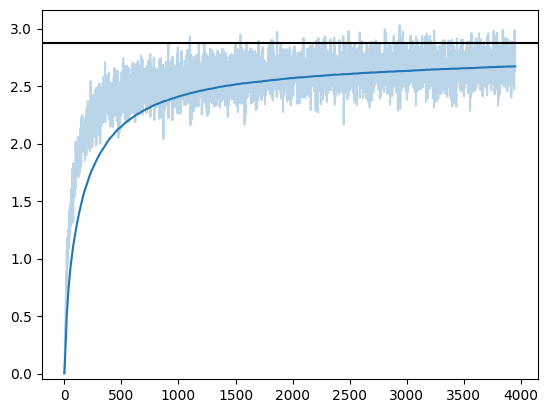

In [7]:
mis = vbmi.InfoNCE(x, y)

EMA_SPAN = 1000
mis_smooth = pd.Series(mis).ewm(span=EMA_SPAN).mean()
p1 = plt.plot(mis, alpha=0.3)[0]
plt.plot(mis_smooth, c=p1.get_color())
plt.axhline(y=exact_mi, c='k', linestyle='-')
#plt.axhline(1 + np.log(batch_size) - 1,
#            c='k', linestyle='--', label=r'1 + log(K/$\alpha$)')
plt.ylim([-0.05, 1.1 * exact_mi])
